In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded ✅")

Libraries loaded ✅


In [22]:
df = pd.read_csv("C:\\Users\\pokal\\OneDrive\\Dokumen\\Hospital-Readmission-Project\\exports\\cleaned_data.csv")
print(f"Data loaded ✅ Shape: {df.shape}")

Data loaded ✅ Shape: (101766, 43)


In [23]:
le = LabelEncoder()
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f"Categorical columns: {cat_cols}")

for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print("Encoding done ✅")

Categorical columns: ['race', 'gender', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']
Encoding done ✅


In [24]:
X = df.drop('readmitted', axis=1)
y = df['readmitted']

print(f"Features: {X.shape[1]}")
print(f"Target distribution:\n{y.value_counts()}")

Features: 42
Target distribution:
readmitted
0    90409
1    11357
Name: count, dtype: int64


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training rows: {X_train.shape[0]}")
print(f"Testing rows: {X_test.shape[0]}")

Training rows: 81412
Testing rows: 20354


In [26]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
print("Model trained ✅")

Model trained ✅


In [27]:
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred))
print(f"ROC AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18083
           1       0.62      0.01      0.02      2271

    accuracy                           0.89     20354
   macro avg       0.76      0.50      0.48     20354
weighted avg       0.86      0.89      0.84     20354

ROC AUC Score: 0.6469


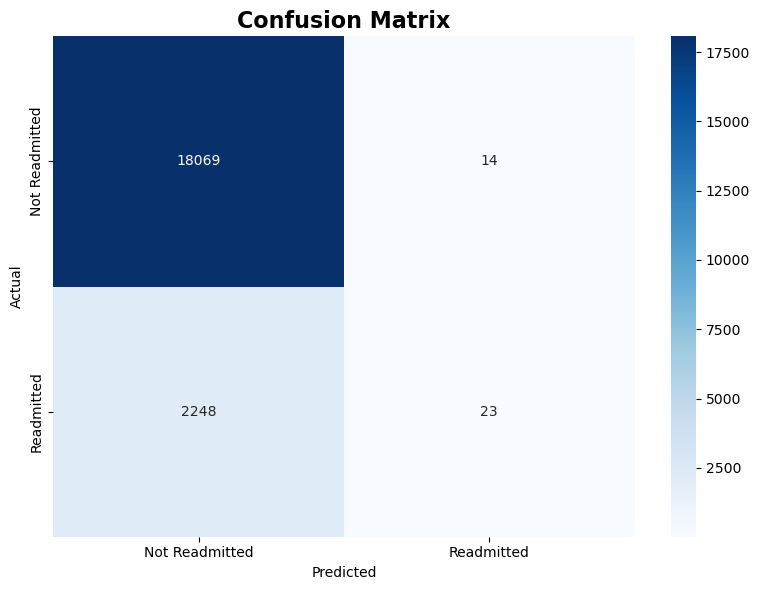

In [28]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Readmitted', 'Readmitted'],
            yticklabels=['Not Readmitted', 'Readmitted'])
plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig("C:\\Users\\pokal\\OneDrive\\Dokumen\\Hospital-Readmission-Project\\exports\\06_confusion_matrix.png", dpi=150)
plt.show()

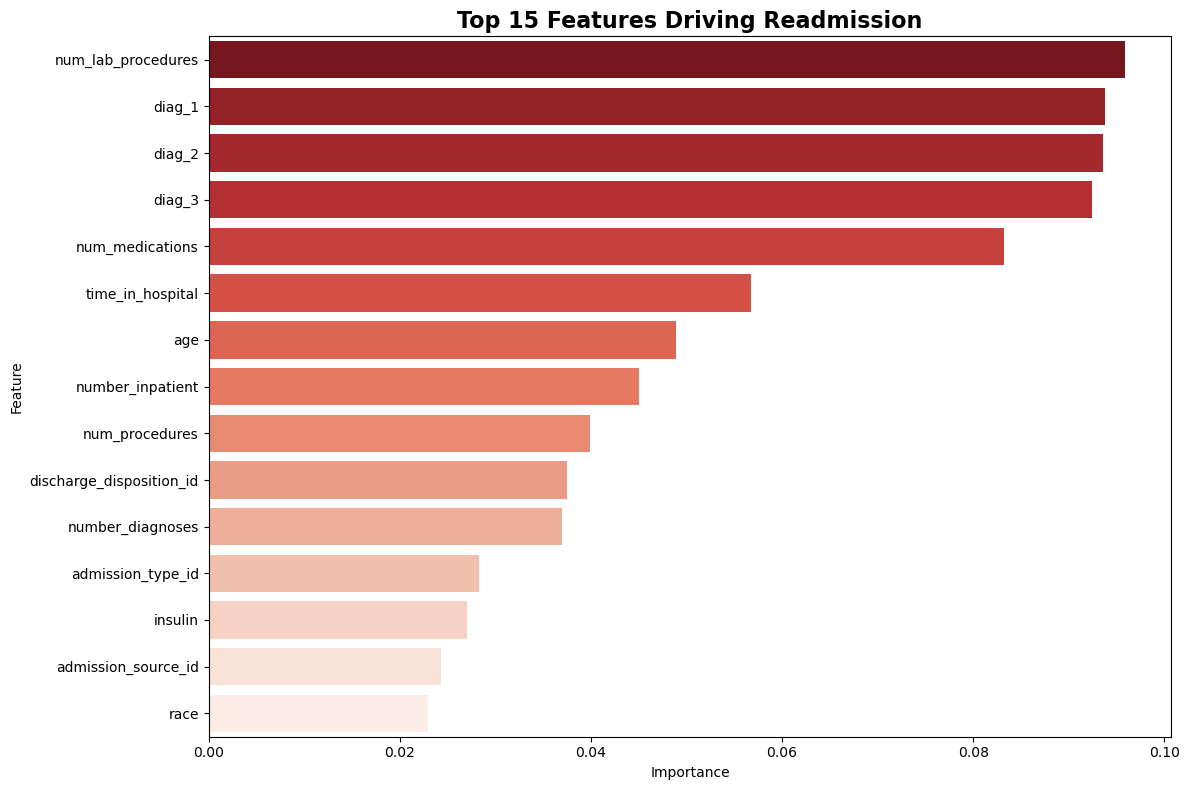

In [29]:
feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(12, 8))
sns.barplot(data=feat_imp, x='Importance', y='Feature', palette='Reds_r')
plt.title('Top 15 Features Driving Readmission', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig("C:\\Users\\pokal\\OneDrive\\Dokumen\\Hospital-Readmission-Project\\exports\\07_feature_importance.png", dpi=150)
plt.show()

In [30]:
df_export = pd.read_csv("C:\\Users\\pokal\\OneDrive\\Dokumen\\Hospital-Readmission-Project\\exports\\cleaned_data.csv")

# Encode again for prediction
for col in df_export.select_dtypes(include='object').columns:
    df_export[col] = le.fit_transform(df_export[col].astype(str))

# Add risk score
df_export['risk_score'] = rf_model.predict_proba(df_export.drop('readmitted', axis=1))[:, 1]

# Add risk level
df_export['risk_level'] = df_export['risk_score'].apply(
    lambda x: 'HIGH RISK' if x >= 0.6 else ('MEDIUM RISK' if x >= 0.4 else 'LOW RISK'))

# Save
df_export.to_csv("C:\\Users\\pokal\\OneDrive\\Dokumen\\Hospital-Readmission-Project\\exports\\final_data_with_risk.csv", index=False)
print("Final data with risk scores saved ✅")
print(df_export['risk_level'].value_counts())

Final data with risk scores saved ✅
risk_level
LOW RISK       92530
HIGH RISK       8732
MEDIUM RISK      504
Name: count, dtype: int64


In [32]:
df = pd.read_csv("C:\\Users\\pokal\\OneDrive\\Dokumen\\Hospital-Readmission-Project\\exports\\final_data_with_risk.csv")
print(df.shape)
print(df.head(2))

(101766, 45)
   race  gender  age  admission_type_id  discharge_disposition_id  \
0     2       0    5                  6                        25   
1     2       0   15                  1                         1   

   admission_source_id  time_in_hospital  num_lab_procedures  num_procedures  \
0                    1                 1                  41               0   
1                    7                 3                  59               0   

   num_medications  ...  glyburide-metformin  glipizide-metformin  \
0                1  ...                    1                    0   
1               18  ...                    1                    0   

   glimepiride-pioglitazone  metformin-rosiglitazone  metformin-pioglitazone  \
0                         0                        0                       0   
1                         0                        0                       0   

   change  diabetesMed  readmitted  risk_score  risk_level  
0       1            0      